## Trend Analysis: Mann-Kendall Test and Theil-Sen Slope

In time series analysis, detecting whether a monotonic trend exists in a data set is a fundamental task. Unlike regression-based trend detection, non-parametric methods do not require assumptions about the distribution of the data, making them especially suitable for environmental and geoscientific data that may contain outliers, missing values, or non-normal distributions.

Two widely used non-parametric methods for trend analysis are:

1. **Mann-Kendall Test** — a hypothesis test for the presence of a monotonic trend.
2. **Theil-Sen Slope Estimator** — a robust estimator of the magnitude of the trend.

These methods are frequently used in hydrology, climatology, and environmental sciences ([Helsel and Hirsch, 2002](https://pubs.usgs.gov/twri/twri4a3/); [Yue et al., 2002](https://doi.org/10.1002/joc.702)).

***

### The Mann-Kendall Test

The [Mann-Kendall test](https://en.wikipedia.org/wiki/Kendall_rank_correlation_coefficient) is a non-parametric statistical test used to identify whether a monotonic upward or downward trend exists in a time series. It was originally proposed by [Mann (1945)](https://doi.org/10.2307/1907187) and later refined by [Kendall (1975)](https://en.wikipedia.org/wiki/Kendall_rank_correlation_coefficient).

Given a time series $y_1, y_2, \ldots, y_n$, the Mann-Kendall test statistic $S$ is defined as:

$$S = \sum_{k=1}^{n-1} \sum_{j=k+1}^{n} \text{sgn}(y_j - y_k)$$

where the sign function is:

$$
\text{sgn}(x) =
\begin{cases}
+1 & \text{if } x > 0 \\
0 & \text{if } x = 0 \\
-1 & \text{if } x < 0
\end{cases}
$$

Under the null hypothesis $H_0$ (no trend), $S$ is approximately normally distributed with:

- Mean: $E[S] = 0$
- Variance: $\text{Var}(S) = \frac{n(n-1)(2n+5)}{18}$

If there are tied groups, the variance is adjusted:

$$\text{Var}(S) = \frac{n(n-1)(2n+5) - \sum_{p=1}^{g} t_p(t_p-1)(2t_p+5)}{18}$$

where $g$ is the number of tied groups and $t_p$ is the number of data points in the $p$-th tied group.

The standardized test statistic $Z$ is:

$$
Z =
\begin{cases}
\frac{S-1}{\sqrt{\text{Var}(S)}} & \text{if } S > 0 \\
0 & \text{if } S = 0 \\
\frac{S+1}{\sqrt{\text{Var}(S)}} & \text{if } S < 0
\end{cases}
$$

A positive $Z$ indicates an upward trend, a negative $Z$ a downward trend. The null hypothesis is rejected if $|Z| > Z_{1-\alpha/2}$.

***

### The Theil-Sen Slope Estimator

The [Theil-Sen slope estimator](https://en.wikipedia.org/wiki/Theil%E2%80%93Sen_estimator) (also known as Sen's slope) provides a robust estimate of the magnitude of a trend. It was proposed by [Theil (1950)](https://doi.org/10.1016/S1385-7258(50)50011-1) and extended by [Sen (1968)](https://doi.org/10.1080/01621459.1968.10480934).

The Theil-Sen slope $\beta$ is defined as the **median** of all pairwise slopes:

$$\beta = \text{median}\left(\frac{y_j - y_k}{j - k}\right), \quad \forall \; k < j$$

Key properties:
- It is **robust to outliers** — up to 29.3% of the data can be outliers without significantly affecting the estimate.
- It does **not assume normality** of residuals.
- It provides a **confidence interval** for the slope.

The intercept is typically estimated as:

$$\alpha = \text{median}(y_i) - \beta \cdot \text{median}(x_i)$$

In [ ]:
%load_ext lab_black

fish: Unknown command: load_ext
fish: 
load_ext lab_black
^


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats

***

### Mann-Kendall Test — Step-by-step implementation

Let's use the same temperature anomaly data from the previous notebook to perform a Mann-Kendall test and estimate the Theil-Sen slope.



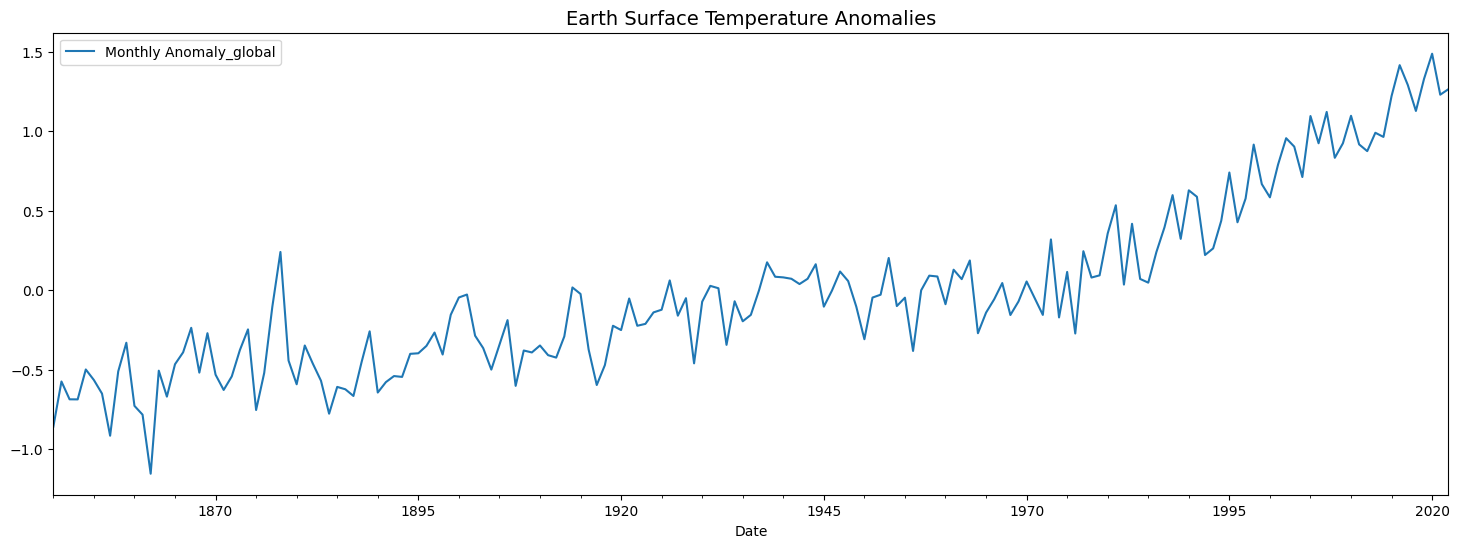

In [ ]:
# Generate synthetic data with a known linear trend + noise
t_global = pd.read_json(
    "http://userpage.fu-berlin.de/soga/soga-py/300/307000_time_series/t_global.json"
)
t_global["Date"] = pd.to_datetime(t_global["Date"], format="%Y-%m-%d", errors="coerce")
t_global = t_global.set_index("Date")["Monthly Anomaly_global"]

y = t_global.groupby(t_global.index.to_period("Y")).agg("mean")["1850-01-01":]

plt.figure(figsize=(18, 6))
plt.title("Earth Surface Temperature Anomalies", fontsize=14)
y.plot()

plt.legend()
plt.show()


***

### Using the `pymannkendall` library

In practice, we typically use a well-tested library. The [`pymannkendall`](https://github.com/mmhs013/pyMannKendall) package provides several variants including the original Mann-Kendall test, the seasonal variant, and corrections for autocorrelation.

In [ ]:
import pymannkendall as mk

mk_result = mk.original_test(y)

print("Mann-Kendall Test Results (pymannkendall)")
print("=" * 50)
print(f"Trend:          {mk_result.trend}")
print(f"p-value:        {mk_result.p:.6f}")
print(f"Z statistic:    {mk_result.z:.4f}")
print(f"Kendall's tau:  {mk_result.Tau:.4f}")


Mann-Kendall Test Results (pymannkendall)
Trend:          increasing
p-value:        0.000000
Z statistic:    14.2608
Kendall's tau:  0.7302


The `pymannkendall` library also returns the Theil-Sen slope and intercept alongside the test results — a convenient feature.

***

### Theil-Sen Slope — Step-by-step implementation

Let us compute the Theil-Sen slope manually, and then compare with `scipy.stats.theilslopes`.

In [ ]:
def theil_sen_slope(x, y):
    """
    Compute the Theil-Sen slope estimator.

    Parameters
    ----------
    x : array-like
        Independent variable (e.g., time index).
    y : array-like
        Dependent variable (observations).

    Returns
    -------
    slope : float
        Median of all pairwise slopes.
    intercept : float
        Median-based intercept.
    """
    n = len(x)
    slopes = []

    for k in range(n):
        for j in range(k + 1, n):
            if x[j] != x[k]:
                slopes.append((y[j] - y[k]) / (x[j] - x[k]))

    slope = np.median(slopes)
    intercept = np.median(y) - slope * np.median(x)

    return slope, intercept, slopes

In [ ]:
slope_manual, intercept_manual, all_slopes = theil_sen_slope(y.index.year, y)

print("Theil-Sen Slope (manual implementation)")
print("=" * 50)
print(f"Slope:     {slope_manual:.6f}")
print(f"Intercept: {intercept_manual:.6f}")


Theil-Sen Slope (manual implementation)
Slope:     0.009166
Intercept: -17.833428


/var/folders/ly/7lr4km0s1wd8h6w0sb8p_1n80000gn/T/ipykernel_68908/3081688310.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slopes.append((y[j] - y[k]) / (x[j] - x[k]))


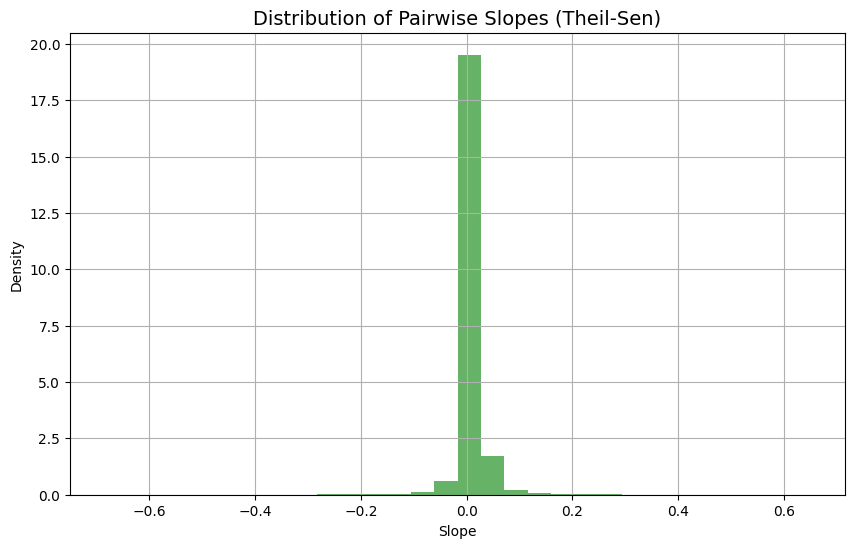

In [ ]:
# plot all_slopes pdf

plt.figure(figsize=(10, 6))
plt.hist(all_slopes, bins=30, density=True, alpha=0.6, color="g")
plt.title("Distribution of Pairwise Slopes (Theil-Sen)", fontsize=14)
plt.xlabel("Slope")
plt.ylabel("Density")
plt.grid()
plt.show()	


Now let us compare with the [`scipy.stats.theilslopes`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.theilslopes.html) function, which also provides confidence intervals.

In [ ]:
ts_result = stats.theilslopes(y, y.index.year, alpha=0.95)

print("Theil-Sen Slope (scipy.stats.theilslopes)")
print("=" * 50)
print(f"Slope:              {ts_result.slope:.6f}")
print(f"Intercept:          {ts_result.intercept:.6f}")
print(f"95% CI lower slope: {ts_result.low_slope:.6f}")
print(f"95% CI upper slope: {ts_result.high_slope:.6f}")

Theil-Sen Slope (scipy.stats.theilslopes)
Slope:              0.009166
Intercept:          -17.833428
95% CI lower slope: 0.008252
95% CI upper slope: 0.010063


Let us visualize the Theil-Sen trend line overlaid on the data.

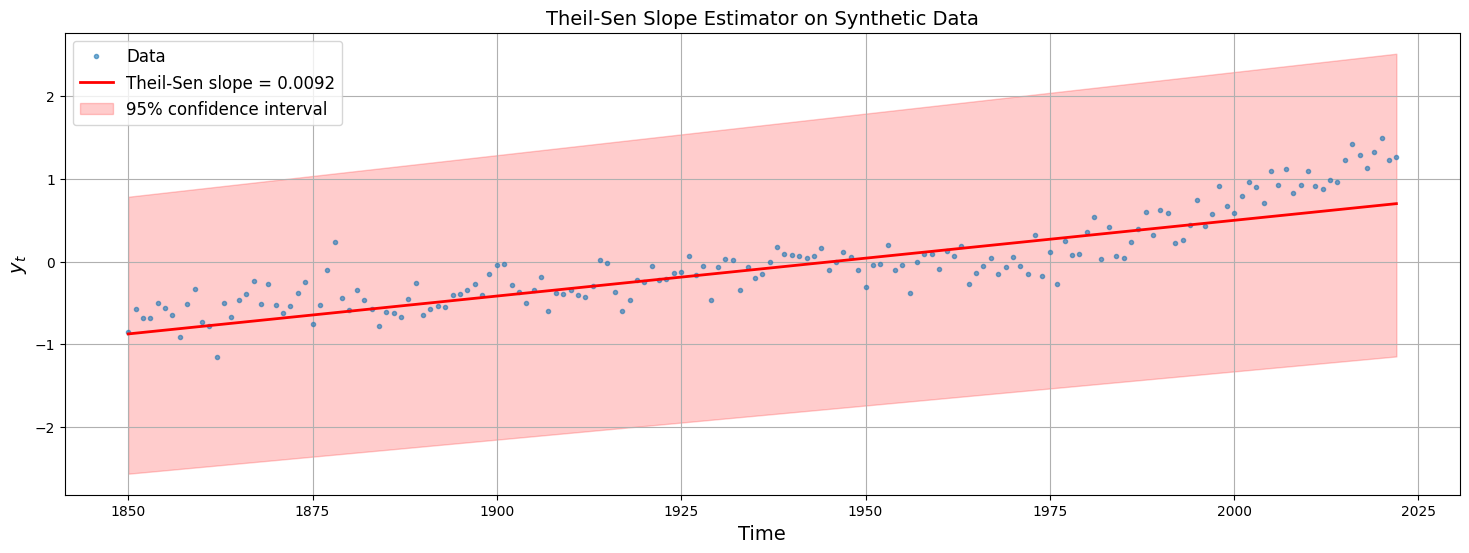

In [ ]:
plt.figure(figsize=(18, 6))
plt.plot(y.index.year, y, "o", markersize=3, label="Data", alpha=0.6)
plt.plot(
    y.index.year,
    ts_result.intercept + ts_result.slope * y.index.year,
    "r-",
    linewidth=2,
    label=f"Theil-Sen slope = {ts_result.slope:.4f}",
)
plt.fill_between(
    y.index.year,
    ts_result.intercept + ts_result.low_slope * y.index.year,
    ts_result.intercept + ts_result.high_slope * y.index.year,
    alpha=0.2,
    color="red",
    label="95% confidence interval",
)
plt.title("Theil-Sen Slope Estimator on Synthetic Data", fontsize=14)
plt.xlabel("Time", fontsize=14)
plt.ylabel("$y_t$", fontsize=14)
plt.legend(fontsize=12)
plt.grid()
plt.show()

***

### Comparison: Theil-Sen Slope vs. Ordinary Least Squares (OLS)

A key advantage of the Theil-Sen estimator is its robustness to outliers. Let us demonstrate this by adding artificial outliers to the data.

In [ ]:
# Add outliers to a copy of the data
y_outliers = y.copy()
outlier_indices = [10, 30, 50, 70, 90]
y_outliers[outlier_indices] += np.array([8, -10, 12, -9, 11])

# OLS regression (least squares) 
ols_slope, ols_intercept, _, _, _ = stats.linregress(y.index.year, y)
ols_slope_outlier, ols_intercept_outlier, _, _, _ = stats.linregress(y.index.year, y_outliers)

# Theil-Sen slope
ts_slope = stats.theilslopes(y, y.index.year, alpha=0.95)
ts_outlier = stats.theilslopes(y_outliers, y.index.year, alpha=0.95)

print("Comparison with outliers")
print("=" * 50)
print(f"OLS slope:        {ols_slope:.6f} | OLS slope with outliers:       {ols_slope_outlier:.6f}")
print(f"Theil-Sen slope:  {ts_slope[0]:.6f} | Theil-Sen slope with outliers: {ts_outlier[0]:.6f}")

Comparison with outliers
OLS slope:        0.009528 | OLS slope with outliers:       0.008851
Theil-Sen slope:  0.009166 | Theil-Sen slope with outliers: 0.009170


/var/folders/ly/7lr4km0s1wd8h6w0sb8p_1n80000gn/T/ipykernel_68908/550024699.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_outliers[outlier_indices] += np.array([8, -10, 12, -9, 11])
/var/folders/ly/7lr4km0s1wd8h6w0sb8p_1n80000gn/T/ipykernel_68908/550024699.py:4: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  y_outliers[outlier_indices] += np.array([8, -10, 12, -9, 11])


/var/folders/ly/7lr4km0s1wd8h6w0sb8p_1n80000gn/T/ipykernel_68908/1579209623.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_outliers[outlier_indices],


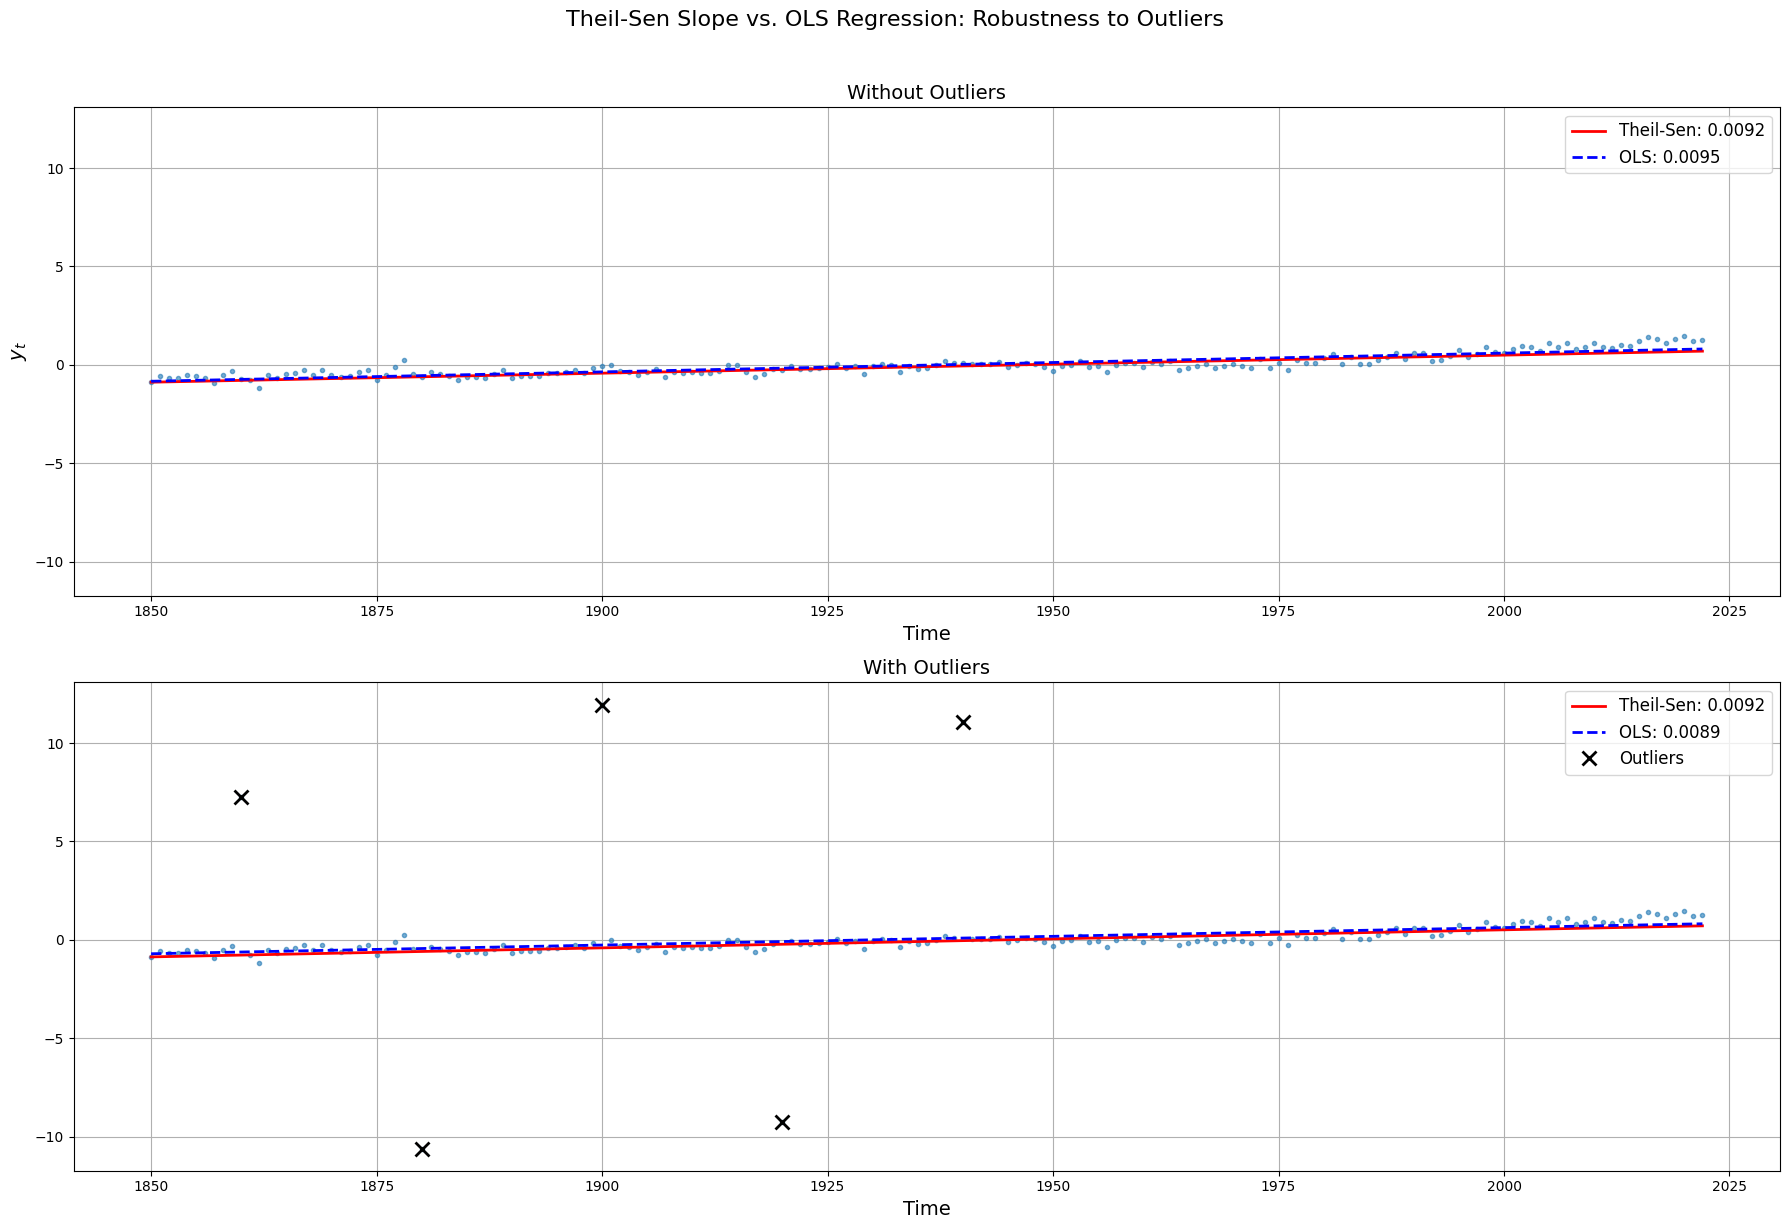

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(18, 12), sharey=True)

# Left: without outliers
axs[0].plot(y.index.year, y, "o", markersize=3, alpha=0.6)
axs[0].plot(
    y.index.year,
    ts_slope.intercept + ts_slope.slope * y.index.year,
    "r-",
    linewidth=2,
    label=f"Theil-Sen: {ts_slope.slope:.4f}",
)
axs[0].plot(
    y.index.year,
    ols_intercept + ols_slope * y.index.year,
    "b--",
    linewidth=2,
    label=f"OLS: {ols_slope:.4f}",
)
axs[0].set_title("Without Outliers", fontsize=14)
axs[0].set_xlabel("Time", fontsize=14)
axs[0].set_ylabel("$y_t$", fontsize=14)
axs[0].legend(fontsize=12)
axs[0].grid()

# Right: with outliers
axs[1].plot(y.index.year, y_outliers, "o", markersize=3, alpha=0.6)
axs[1].plot(
    y.index.year,
    ts_outlier.intercept + ts_outlier.slope * y.index.year,
    "r-",
    linewidth=2,
    label=f"Theil-Sen: {ts_outlier.slope:.4f}",
)
axs[1].plot(
    y.index.year,
    ols_intercept_outlier + ols_slope_outlier * y.index.year,
    "b--",
    linewidth=2,
    label=f"OLS: {ols_slope_outlier:.4f}",
)
axs[1].plot(
    y.index.year[outlier_indices],
    y_outliers[outlier_indices],
    "kx",
    markersize=10,
    markeredgewidth=2,
    label="Outliers",
)
axs[1].set_title("With Outliers", fontsize=14)
axs[1].set_xlabel("Time", fontsize=14)
axs[1].legend(fontsize=12)
axs[1].grid()

plt.suptitle(
    "Theil-Sen Slope vs. OLS Regression: Robustness to Outliers",
    fontsize=16,
    y=1.02,
)
plt.tight_layout()
plt.show()

Note how the value of the OLS slope changes dramatically with the introduction of outliers, while the Theil-Sen slope remains relatively stable, illustrating its robustness.

***

### When to use which test?

The `pymannkendall` library offers several variants of the Mann-Kendall test:

| Test | Use case |
|------|----------|
| `original_test` | Standard Mann-Kendall test for independent data |
| `hamed_rao_modification_test` | Data with significant autocorrelation (modified variance) |
| `yue_wang_modification_test` | Similar autocorrelation correction with a different approach |
| `seasonal_test` | Data with a seasonal component (e.g., monthly data) |
| `regional_test` | Multiple related time series (spatial data) |

When autocorrelation is present, the standard Mann-Kendall test may overestimate the significance of the trend. Let us check for autocorrelation and apply the corrected test.

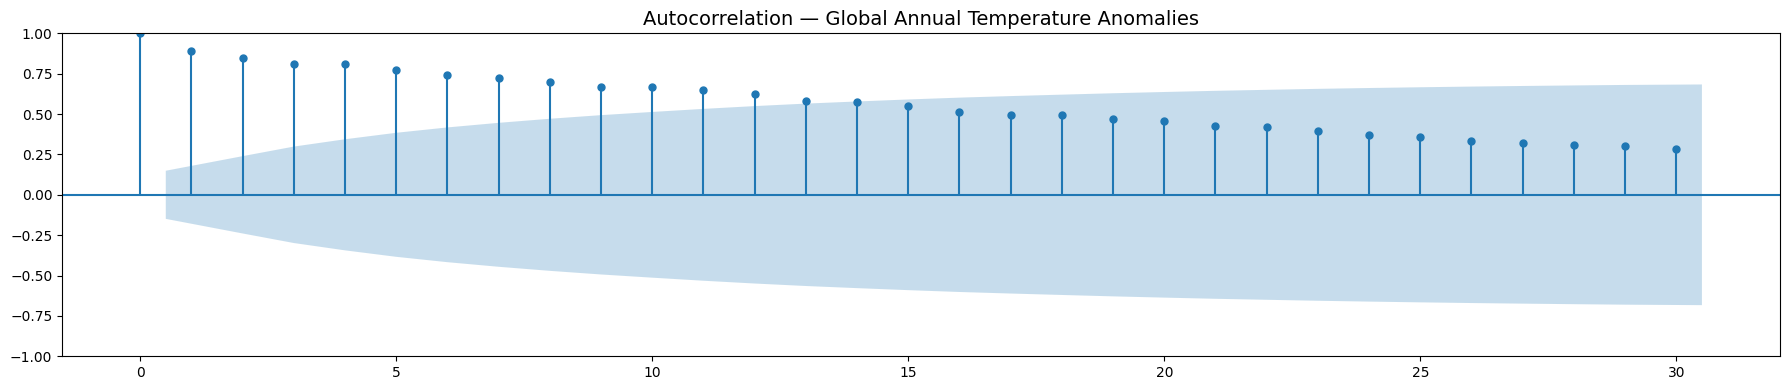

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(18, 4))
plot_acf(y.values, ax=ax, lags=30)
ax.set_title(
    "Autocorrelation — Global Annual Temperature Anomalies",
    fontsize=14,
)
plt.tight_layout()
plt.show()

In [73]:
# Hamed-Rao modified Mann-Kendall test (autocorrelation corrected)
mk_hamed = mk.hamed_rao_modification_test(temp_annual.values)

print("Hamed-Rao Modified Mann-Kendall Test")
print("=" * 50)
print(f"Trend:          {mk_hamed.trend}")
print(f"p-value:        {mk_hamed.p:.6e}")
print(f"Z statistic:    {mk_hamed.z:.4f}")
print(f"Kendall's tau:  {mk_hamed.Tau:.4f}")
print(f"Sen's slope:    {mk_hamed.slope:.6f} °C/year")
print()
print("Comparison with original test:")
print(f"  Original p-value: {mk_temp.p:.6e}")
print(f"  Hamed-Rao p-value: {mk_hamed.p:.6e}")

Hamed-Rao Modified Mann-Kendall Test
Trend:          increasing
p-value:        1.690853e-06
Z statistic:    4.7872
Kendall's tau:  0.6306
Sen's slope:    0.006710 °C/year

Comparison with original test:
  Original p-value: 0.000000e+00
  Hamed-Rao p-value: 1.690853e-06



***

## Exercises on Trend Analysis: Mann-Kendall Test and Theil-Sen Slope

> **Exercise 1:** Load the Antarctica ice core $CO_2$ data from the URL below. Apply the Mann-Kendall test and Theil-Sen slope. Interpret the results.
>
> URL: `http://userpage.fu-berlin.de/soga/soga-py/300/307000_time_series/Antartica_Ice_Core.json`

In [ ]:
## Your code here ...

> **Exercise 2:** Generate a synthetic time series with a **decreasing** trend (e.g., slope = $-0.03$). Apply the Mann-Kendall test and verify that it correctly identifies the direction of the trend. Plot the result with the Theil-Sen trend line.

In [ ]:
## Your code here ...

> **Exercise 3:** Investigate how sample size affects the power of the Mann-Kendall test. Generate synthetic data with a weak trend (slope = $0.01$) for sample sizes $n = 20, 50, 100, 200, 500$. For each, run the test 1000 times with different random noise, and compute the fraction of times the test correctly rejects $H_0$. Plot the rejection rate as a function of $n$.

In [ ]:
## Your code here ...

***

Summary:

* The **Mann-Kendall test** is a non-parametric test for detecting monotonic trends in time series. It does not assume normality and is robust to outliers and missing data.
* The **Theil-Sen slope** provides a robust estimate of the trend magnitude. Unlike OLS, it is resistant to outliers.
* When the data exhibits **autocorrelation**, modified versions of the Mann-Kendall test (e.g., Hamed-Rao) should be used to avoid inflated significance.
* Both methods are widely used in environmental and geoscientific applications for trend detection in temperature, precipitation, streamflow, and other variables.